# Malware Detection with SGD
LSTM classifier trained with Stochastic Gradient Descent on opcode sequences.

In [4]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from collections import Counter

torch.manual_seed(42)
np.random.seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


## Config

In [ ]:
MAX_SEQ_LEN           = 200
VOCAB_SIZE            = 300
BATCH_SIZE            = 64
NUM_EPOCHS            = 30
LR                    = 0.01
MIN_SAMPLES_PER_CLASS = 25   # opcode families with fewer samples than this are dropped

## Data Pipeline
Loads from cache (`input/X.pt`, `input/y.pt`, `input/meta.json`) if it exists â€” takes ~15 seconds.
On first run reads the zip, filters rare families, encodes sequences, and saves the cache â€” slow but only happens once.

In [6]:
import zipfile, json as _json, os
import numpy as np

CACHE_X    = 'input/X.pt'
CACHE_Y    = 'input/y.pt'
CACHE_META = 'input/meta.json'

if os.path.exists(CACHE_X) and os.path.exists(CACHE_Y) and os.path.exists(CACHE_META):
    # ---- fast path: load pre-processed tensors ----
    X = torch.load(CACHE_X)
    y = torch.load(CACHE_Y)
    with open(CACHE_META) as f:
        meta = _json.load(f)
    vocab_size  = meta['vocab_size']
    num_classes = meta['num_classes']
    label_map   = meta['label_map']
    print(f"Loaded from cache â€” {X.shape[0]:,} samples, {num_classes} classes")

else:
    # ---- slow path: read zip, filter, encode, save cache ----
    print("Cache not found â€” processing from zip (one-time)...")

    # 1. read zip
    rows, label_map = [], {}
    with zipfile.ZipFile('input/opcodes.zip') as z:
        entries = [e for e in z.infolist()
                   if not e.filename.endswith('/') and e.file_size > 0
                   and len(e.filename.split('/')) >= 3]
        print(f"  Reading {len(entries):,} files from zip...")
        for i, entry in enumerate(entries):
            parts  = entry.filename.split('/')
            family = parts[1]
            if family not in label_map:
                label_map[family] = len(label_map)
            raw = z.read(entry.filename).decode('utf-8', errors='replace')
            rows.append({'opcodes': ' '.join(raw.split()), 'label': label_map[family]})
            if (i + 1) % 25000 == 0:
                print(f"    {i+1:,} / {len(entries):,} files read...")
    df = pd.DataFrame(rows)
    print(f"  Read {len(df):,} samples, {df['label'].nunique()} families")

    # 2. filter rare families
    counts        = df['label'].value_counts()
    keep          = counts[counts >= MIN_SAMPLES_PER_CLASS].index
    df            = df[df['label'].isin(keep)].copy()
    unique_labels = sorted(df['label'].unique())
    remap         = {old: new for new, old in enumerate(unique_labels)}
    df['label']   = df['label'].map(remap)
    label_map     = {fam: remap[idx] for fam, idx in label_map.items() if idx in remap}
    print(f"  After filtering: {len(df):,} samples, {df['label'].nunique()} classes")

    # 3. build vocab
    token_counts = Counter()
    for seq in df['opcodes']:
        token_counts.update(seq.split())
    most_common = [tok for tok, _ in token_counts.most_common(VOCAB_SIZE - 2)]
    token2idx   = {tok: i + 2 for i, tok in enumerate(most_common)}
    vocab_size  = len(token2idx) + 2
    print(f"  Vocab built â€” {vocab_size} tokens")

    # 4. encode into pre-allocated numpy array (avoids huge list-of-lists â€” much faster)
    print(f"  Encoding {len(df):,} sequences...")
    opcodes_list = df['opcodes'].tolist()
    n    = len(opcodes_list)
    X_np = np.zeros((n, MAX_SEQ_LEN), dtype=np.int32)  # 0 = PAD
    for i, seq in enumerate(opcodes_list):
        tokens = seq.split()[:MAX_SEQ_LEN]
        for j, t in enumerate(tokens):
            X_np[i, j] = token2idx.get(t, 1)           # 1 = UNK
        if (i + 1) % 25000 == 0:
            print(f"    {i+1:,} / {n:,} encoded...")
    X           = torch.from_numpy(X_np).long()
    y           = torch.tensor(df['label'].values, dtype=torch.long)
    num_classes = int(y.unique().size(0))
    print(f"  Encoded â€” shape: {X.shape}")

    # 5. save cache
    torch.save(X, CACHE_X)
    torch.save(y, CACHE_Y)
    with open(CACHE_META, 'w') as f:
        _json.dump({'vocab_size': vocab_size, 'num_classes': num_classes,
                    'label_map': label_map}, f)
    print("  Cache saved â€” future runs will load in ~15 seconds")

Loaded from cache â€” 206,738 samples, 309 classes


In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val,  y_train, y_val  = train_test_split(X_train, y_train, test_size=0.1, random_state=42)

val_loader  = DataLoader(TensorDataset(X_val,  y_val),  batch_size=BATCH_SIZE)
test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=BATCH_SIZE)

print(f"Train: {len(X_train)}  Val: {len(X_val)}  Test: {len(X_test)}")

# SGD iterates over a shuffled DataLoader (shuffle handled by PyTorch internally)
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)

Train: 148851  Val: 16539  Test: 41348


## Model
Embedding â†’ LSTM â†’ Linear.

In [8]:
class MalwareLSTM(nn.Module):
    def __init__(self):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, 64, padding_idx=0)
        self.lstm = nn.LSTM(64, 128, num_layers=2, batch_first=True, dropout=0.3)
        self.fc   = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.embedding(x)
        _, (hidden, _) = self.lstm(x)
        return self.fc(hidden[-1])

model = MalwareLSTM().to(device)
print(model)

MalwareLSTM(
  (embedding): Embedding(300, 64, padding_idx=0)
  (lstm): LSTM(64, 128, num_layers=2, batch_first=True, dropout=0.3)
  (fc): Linear(in_features=128, out_features=309, bias=True)
)


## SGD Optimizer and Loss

In [9]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=LR, momentum=0.9)

## Training Loop

In [10]:
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

for epoch in range(1, NUM_EPOCHS + 1):
    # ---- train ----
    model.train()
    total_loss, correct, total = 0, 0, 0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        out  = model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * xb.size(0)
        correct    += (out.argmax(1) == yb).sum().item()
        total      += yb.size(0)

    train_loss = total_loss / total
    train_acc  = correct / total
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)

    # ---- validate ----
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            out = model(xb)
            val_loss    += criterion(out, yb).item() * xb.size(0)
            val_correct += (out.argmax(1) == yb).sum().item()
            val_total   += yb.size(0)

    v_loss = val_loss / val_total
    v_acc  = val_correct / val_total
    history['val_loss'].append(v_loss)
    history['val_acc'].append(v_acc)

    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:>2} | "
              f"Train Loss: {train_loss:.4f}  Acc: {train_acc:.2%} | "
              f"Val Loss: {v_loss:.4f}  Acc: {v_acc:.2%}")

Epoch  1 | Train Loss: 3.5918  Acc: 35.23% | Val Loss: 3.1400  Acc: 39.34%
Epoch  5 | Train Loss: 2.1297  Acc: 53.79% | Val Loss: 2.0283  Acc: 55.23%
Epoch 10 | Train Loss: 1.5884  Acc: 63.42% | Val Loss: 1.5812  Acc: 62.41%
Epoch 15 | Train Loss: 1.3426  Acc: 68.08% | Val Loss: 1.3471  Acc: 68.93%
Epoch 20 | Train Loss: 1.1796  Acc: 71.02% | Val Loss: 1.2465  Acc: 70.29%
Epoch 25 | Train Loss: 1.0728  Acc: 73.08% | Val Loss: 1.1642  Acc: 72.31%
Epoch 30 | Train Loss: 1.2126  Acc: 70.05% | Val Loss: 1.4152  Acc: 66.17%


## Training Curves

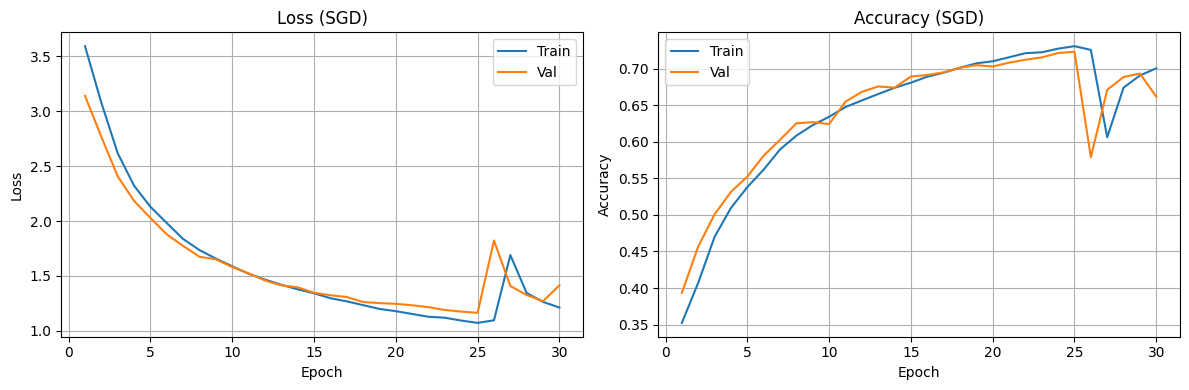

In [11]:
epochs = range(1, NUM_EPOCHS + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs, history['train_loss'], label='Train')
ax1.plot(epochs, history['val_loss'],   label='Val')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.set_title('Loss (SGD)'); ax1.legend(); ax1.grid(True)

ax2.plot(epochs, history['train_acc'], label='Train')
ax2.plot(epochs, history['val_acc'],   label='Val')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
ax2.set_title('Accuracy (SGD)'); ax2.legend(); ax2.grid(True)

plt.tight_layout()
plt.savefig('output/sgd_curves.png', dpi=150)
plt.show()

## Test Evaluation

In [12]:
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        preds = model(xb.to(device)).argmax(1).cpu()
        all_preds.extend(preds.numpy())
        all_labels.extend(yb.numpy())
print(classification_report(all_labels, all_preds))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        23
           1       0.00      0.00      0.00        13
           2       0.84      0.29      0.43       227
           3       0.00      0.00      0.00        36
           4       0.00      0.00      0.00        44
           5       0.96      0.37      0.54        70
           6       0.57      1.00      0.73        91
           7       0.31      0.73      0.44       512
           8       0.38      0.31      0.34       122
           9       0.00      0.00      0.00        12
          10       0.81      0.68      0.74        25
          11       0.81      0.44      0.57       187
          12       0.82      0.16      0.27        87
          13       0.00      0.00      0.00        35
          14       0.00      0.00      0.00        52
          15       0.00      0.00      0.00        63
          16       0.93      0.88      0.90       601
          17       0.00    

c:\Users\harun\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\harun\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\harun\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

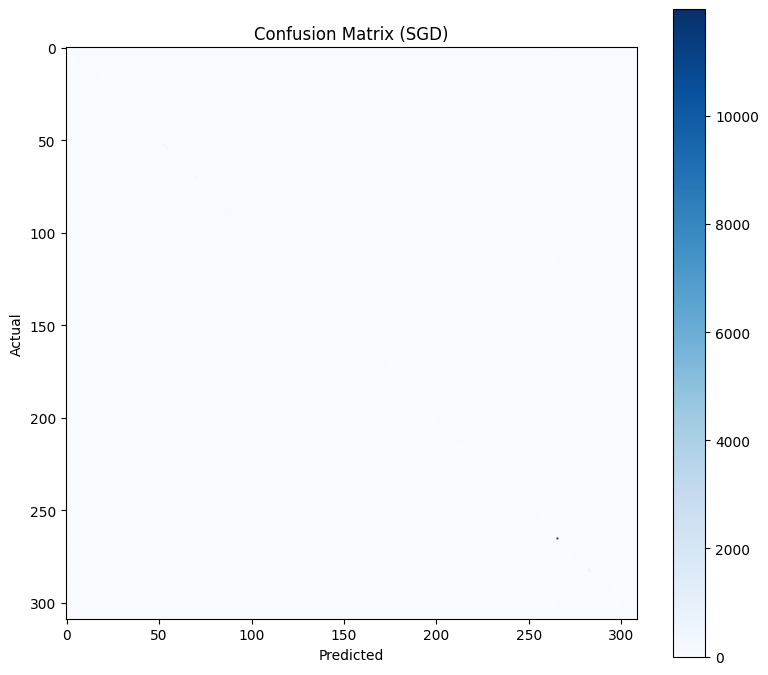

In [13]:
cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(cm, cmap='Blues')
plt.colorbar(im, ax=ax)
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix (SGD)')
plt.tight_layout()
plt.savefig('output/sgd_confusion.png', dpi=150)
plt.show()

## Save

In [14]:
import json, os

os.makedirs("output", exist_ok=True)

with open('output/sgd_history.json', 'w') as f:
    json.dump(history, f)

torch.save(model.state_dict(), 'output/sgd_model.pt')

test_acc = sum(p == l for p, l in zip(all_preds, all_labels)) / len(all_labels)
print(f"Test accuracy: {test_acc:.2%}")
print('Saved to output/: sgd_history.json, sgd_model.pt, sgd_curves.png, sgd_confusion.png')

Test accuracy: 66.28%
Saved sgd_history.json, sgd_model.pt, sgd_curves.png, sgd_confusion.png
